# XGBoost vs LightGBM - Diabetes Prediction

## Objective
To compare the performance of XGBoost and LightGBM models on a diabetes dataset.

In [1]:
!pip install xgboost lightgbm

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

In [4]:
df = pd.read_csv("diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [5]:
cols_with_zero = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

df[cols_with_zero] = df[cols_with_zero].replace(0, np.nan)

In [6]:
df.isnull().sum()

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

In [7]:
df.fillna(df.median(numeric_only=True), inplace=True)

In [8]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

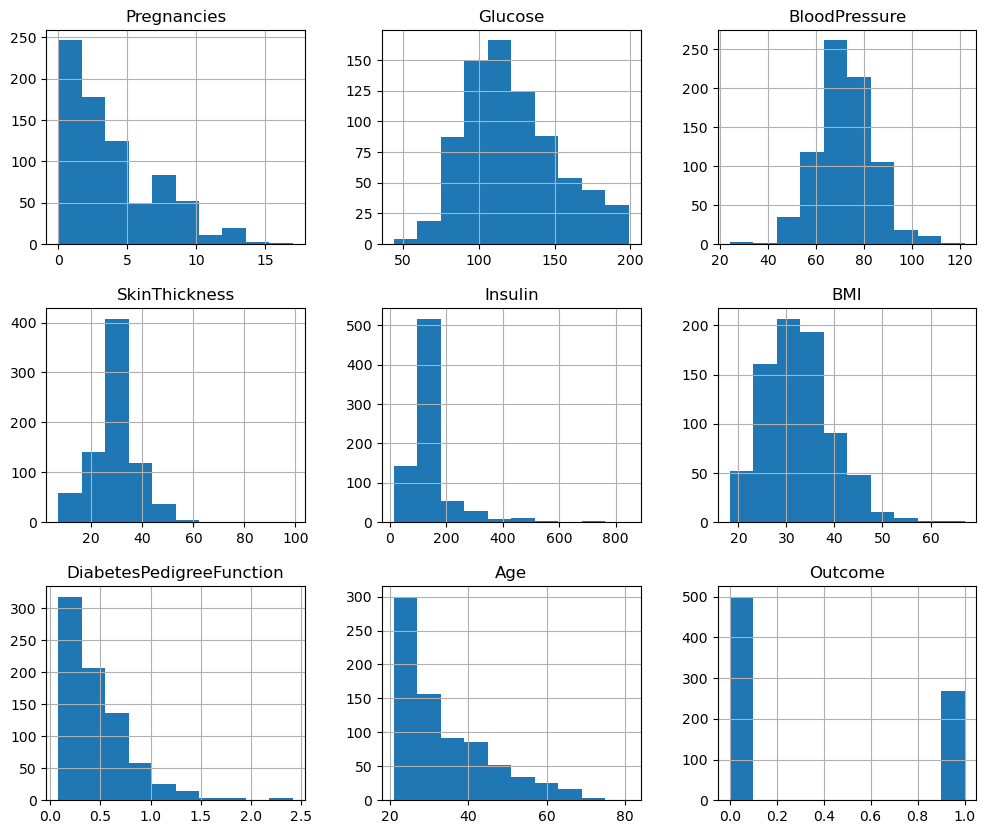

In [9]:
df.hist(figsize=(12,10))
plt.show()

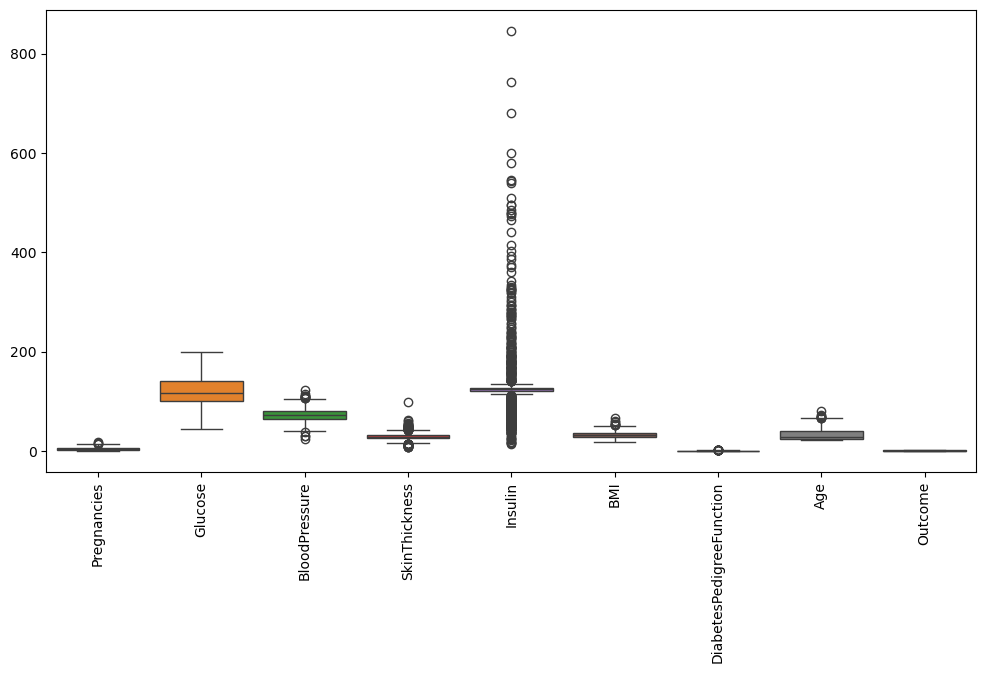

In [10]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.show()

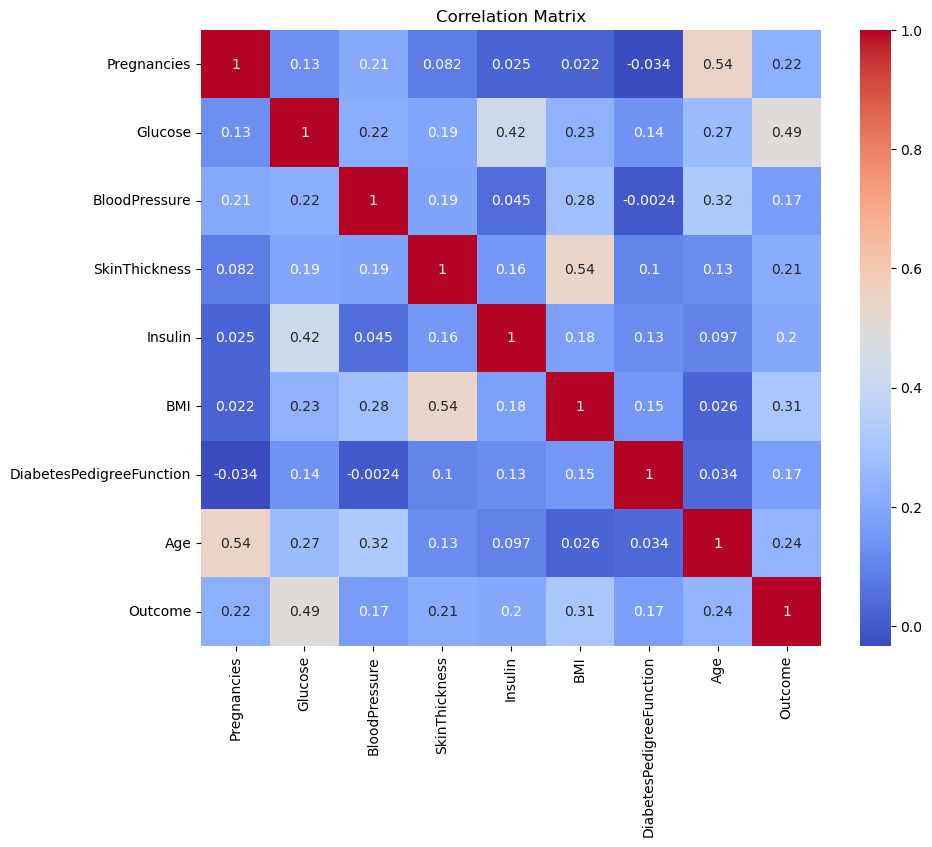

In [11]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

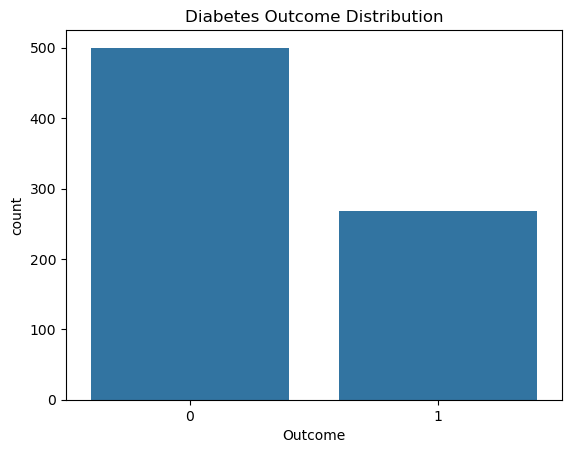

In [12]:
sns.countplot(x=df['Outcome'])
plt.title("Diabetes Outcome Distribution")
plt.show()

## Exploratory Data Analysis

- The dataset is moderately imbalanced, with more non-diabetic cases than diabetic cases.
- Glucose shows the strongest correlation with diabetes outcome, followed by BMI and Age.
- Several features such as Insulin and SkinThickness contain significant outliers.
- Most features are right-skewed, but this does not significantly impact tree-based models.

These observations suggest that glucose and BMI are key predictors of diabetes.

In [13]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [14]:
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))

XGBoost Accuracy: 0.7597402597402597
              precision    recall  f1-score   support

           0       0.80      0.84      0.82       100
           1       0.67      0.61      0.64        54

    accuracy                           0.76       154
   macro avg       0.74      0.73      0.73       154
weighted avg       0.76      0.76      0.76       154



C:\Users\rajur\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [16:03:12] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [15]:
lgbm_model = LGBMClassifier()

lgbm_model.fit(X_train, y_train)

y_pred_lgbm = lgbm_model.predict(X_test)

print("LightGBM Accuracy:", accuracy_score(y_test, y_pred_lgbm))
print(classification_report(y_test, y_pred_lgbm))

[LightGBM] [Info] Number of positive: 214, number of negative: 400
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000086 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 664
[LightGBM] [Info] Number of data points in the train set: 614, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.348534 -> initscore=-0.625489
[LightGBM] [Info] Start training from score -0.625489
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


## Model Comparison: XGBoost vs LightGBM

- Both XGBoost and LightGBM achieved similar performance (~76–77% accuracy).
- LightGBM performed slightly better in detecting diabetic cases (higher recall for class 1).
- However, both models struggled with minority class prediction due to dataset imbalance.

This indicates that the limitation lies more in the dataset rather than the algorithm.

## Strengths and Weaknesses

### XGBoost:
- More regularized and robust
- Better control over overfitting
- Slightly slower than LightGBM

### LightGBM:
- Faster and more efficient
- Uses leaf-wise tree growth
- Can overfit on small datasets

In this case, both models show similar performance.

## Handling Imbalanced Data

The dataset is moderately imbalanced, with more non-diabetic cases than diabetic cases.

To address this:
- Stratified sampling was used during train-test split
- Evaluation focused on recall and F1-score rather than accuracy

Further improvements could include techniques like SMOTE or class weighting.

## Conclusion

Both XGBoost and LightGBM performed similarly on the diabetes dataset.

- LightGBM showed slightly better recall for diabetic cases.
- However, both models struggled due to class imbalance.

Thus, while boosting models are powerful, data quality and balance play a crucial role in performance.